# Geospatial Plume AI Training Notebook
This notebook loads the EDA ConvLSTM dataset, trains a machine learning model to predict next-frame plume concentration, evaluates it, and saves a trained model artifact.


In [27]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


## Feature List

The model uses 801 input features organized into three groups:

### 1. Plume Concentration (768 features)
- 3 input frames × 16×16 downsampled grid = 768 values

### 2. Meteorology Features (45 features)
- **9 meteorological channels** averaged over the spatial grid:
  - `u10m_ms` – 10m zonal wind component
  - `v10m_ms` – 10m meridional wind component
  - `wspd10_ms` – 10m wind speed
  - `wdir_sin` – wind direction sine component ⚡ amplified 3x
  - `wdir_cos` – wind direction cosine component ⚡ amplified 3x
  - `pblh_m` – planetary boundary layer height
  - `sfcp_hpa` – surface pressure
  - `rh2m_pct` – 2m relative humidity
  - `t02m_k` – 2m temperature
- For 3 timesteps: 9 channels × 3 frames = 27 features
- Plus 3× amplified wind direction: 6 features
- Total: 27 + 18 = 45 features

### 3. Plume Summary Statistics (6 features)
- Per input frame: mean and max concentration
- 3 frames × 2 stats = 6 features

**Target:** Next-frame plume concentration at 16×16 resolution (256 values)


In [28]:
# Generate feature list

all_features = []

# 1. Plume concentration features
for t in range(3):
    for y in range(16):
        for x in range(16):
            all_features.append(f"plume_t{t}_y{y}_x{x}")

# 2. Meteorology features
met_channels = [
    "u10m_ms",
    "v10m_ms",
    "wspd10_ms",
    "wdir_sin",
    "wdir_cos",
    "pblh_m",
    "sfcp_hpa",
    "rh2m_pct",
    "t02m_k",
]
for t in range(3):
    for channel in met_channels:
        all_features.append(f"{channel}_t{t}")

# 2b. Amplified wind direction features
for replica in range(3):
    for t in range(3):
        all_features.append(f"wdir_sin_t{t}_amp{replica}")
        all_features.append(f"wdir_cos_t{t}_amp{replica}")

# 3. Plume summary statistics
for t in range(3):
    all_features.append(f"concentration_mean_t{t}")
    all_features.append(f"concentration_max_t{t}")

print(f"Total features: {len(all_features)}")
print(f"\nBreakdown:")
print(f"  Plume concentration: {768}")
print(f"  Meteorology (including amplified wind direction): {45}")
print(f"  Plume statistics: {6}")
print(f"\nFirst 20 features:")
for i, fname in enumerate(all_features[:20]):
    print(f"  {i}: {fname}")
print(f"\nWind direction features (original and amplified):")
wdir_indices = [i for i, f in enumerate(all_features) if "wdir" in f]
for i in wdir_indices[:12]:
    print(f"  {i}: {all_features[i]}")


Total features: 819

Breakdown:
  Plume concentration: 768
  Meteorology (including amplified wind direction): 45
  Plume statistics: 6

First 20 features:
  0: plume_t0_y0_x0
  1: plume_t0_y0_x1
  2: plume_t0_y0_x2
  3: plume_t0_y0_x3
  4: plume_t0_y0_x4
  5: plume_t0_y0_x5
  6: plume_t0_y0_x6
  7: plume_t0_y0_x7
  8: plume_t0_y0_x8
  9: plume_t0_y0_x9
  10: plume_t0_y0_x10
  11: plume_t0_y0_x11
  12: plume_t0_y0_x12
  13: plume_t0_y0_x13
  14: plume_t0_y0_x14
  15: plume_t0_y0_x15
  16: plume_t0_y1_x0
  17: plume_t0_y1_x1
  18: plume_t0_y1_x2
  19: plume_t0_y1_x3

Wind direction features (original and amplified):
  771: wdir_sin_t0
  772: wdir_cos_t0
  780: wdir_sin_t1
  781: wdir_cos_t1
  789: wdir_sin_t2
  790: wdir_cos_t2
  795: wdir_sin_t0_amp0
  796: wdir_cos_t0_amp0
  797: wdir_sin_t1_amp0
  798: wdir_cos_t1_amp0
  799: wdir_sin_t2_amp0
  800: wdir_cos_t2_amp0


In [29]:
# Dataset location and sample inspection
DATA_DIR = Path("../EDA/data").resolve()
WINDOWS_DIR = DATA_DIR / "windows"
print("Data directory:", DATA_DIR)
print("Window files found:", len(list(WINDOWS_DIR.glob("*.npz"))))

sample_path = sorted(WINDOWS_DIR.glob("*.npz"))[0]
with np.load(sample_path, allow_pickle=True) as data:
    print("Sample file:", sample_path.name)
    print("Keys:", data.files)
    print("Input shape:", data["input"].shape)
    print("Target shape:", data["target"].shape)
    print("Input dtype:", data["input"].dtype)
    print("Target dtype:", data["target"].dtype)


Data directory: C:\Users\joaoh\Documents\GitHub\Geospatial-Forecasting\EDA\data
Window files found: 40215
Sample file: 000003_000.npz
Keys: ['scenario_id', 'window_id', 'input', 'target']
Input shape: (3, 10, 64, 64)
Target shape: (1, 10, 64, 64)
Input dtype: float32
Target dtype: float32


In [30]:
def downsample_grid(grid: np.ndarray, factor: int = 4) -> np.ndarray:
    if grid.ndim != 2:
        raise ValueError("Expected a 2D grid for downsampling.")
    h, w = grid.shape
    if h % factor != 0 or w % factor != 0:
        raise ValueError("Grid dimensions must be divisible by downsample factor.")
    return grid.reshape(h // factor, factor, w // factor, factor).mean(axis=(1, 3))


def extract_features(input_window: np.ndarray) -> np.ndarray:
    concentration_frames = input_window[:, 0, :, :]
    downsampled = np.stack([downsample_grid(frame, factor=4) for frame in concentration_frames], axis=0)
    concentration_flat = downsampled.ravel()

    meteorology = input_window[:, 1:10, :, :]
    meteorology_summary = meteorology.mean(axis=(2, 3)).ravel()

    wind_direction = meteorology[:, 3:5, :, :].mean(axis=(2, 3)).ravel()
    wind_direction_amplified = np.tile(wind_direction, 3)

    concentration_stats = []
    for frame in concentration_frames:
        concentration_stats.append(frame.mean())
        concentration_stats.append(frame.max())
    concentration_stats = np.asarray(concentration_stats, dtype=np.float32)

    return np.concatenate((concentration_flat, meteorology_summary, wind_direction_amplified, concentration_stats), axis=0)


def extract_target(target_window: np.ndarray) -> np.ndarray:
    target_plume = target_window[0, 0, :, :]
    return downsample_grid(target_plume, factor=4).ravel()


def build_dataset(paths, max_samples=None, random_seed=42):
    selected = sorted(paths)
    if max_samples is not None:
        np.random.seed(random_seed)
        selected = np.random.permutation(selected)[:max_samples]

    X = []
    y = []
    for path in selected:
        with np.load(path, allow_pickle=True) as data:
            X.append(extract_features(data["input"]))
            y.append(extract_target(data["target"]))

    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32)


def build_model():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", Ridge(alpha=1.0, random_state=42)),
    ])


In [31]:
window_paths = sorted(WINDOWS_DIR.glob("*.npz"))
X, y = build_dataset(window_paths, max_samples=2000)
print("Model input shape:", X.shape)
print("Target shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = build_model()
model.fit(X_train, y_train)

pred = model.predict(X_test)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred, multioutput="uniform_average")

print(f"Test RMSE: {rmse:.6f}")
print(f"Test R^2: {r2:.6f}")

MODEL_PATH = Path("trained_plume_model.pkl")
with MODEL_PATH.open("wb") as f:
    import pickle
    pickle.dump({"model": model, "input_shape": X.shape, "target_shape": y.shape}, f)

print(f"Saved trained model to {MODEL_PATH}")


Model input shape: (2000, 819)
Target shape: (2000, 256)
Test RMSE: 0.467048
Test R^2: 0.680868
Saved trained model to trained_plume_model.pkl


Top 15 most influential features (by average absolute linear coefficient):
plume_t2_y6_x0                 0.094846
plume_t1_y14_x14               0.093937
plume_t0_y10_x13               0.091141
plume_t1_y12_x8                0.091033
plume_t1_y15_x0                0.089548
plume_t1_y0_x15                0.088576
plume_t1_y14_x11               0.088057
plume_t1_y6_x1                 0.087300
plume_t2_y3_x12                0.086553
plume_t2_y2_x3                 0.085807
plume_t1_y8_x1                 0.085789
plume_t1_y3_x10                0.084898
plume_t2_y7_x0                 0.083924
plume_t0_y0_x15                0.083293
plume_t1_y10_x13               0.082862

Average absolute influence by feature group:
  plume downsampled values: 0.059028
  meteorology summary values: 0.031945
  plume mean/max stats: 0.015526


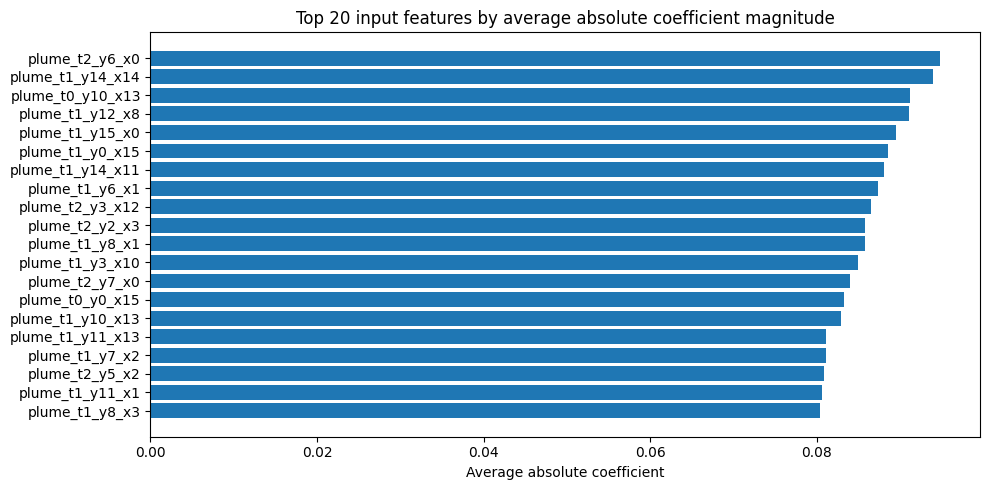

In [32]:
# Feature influence analysis

feature_names = []
for t in range(3):
    for y in range(16):
        for x in range(16):
            feature_names.append(f"plume_t{t}_y{y}_x{x}")

met_channels = [
    "u10m_ms",
    "v10m_ms",
    "wspd10_ms",
    "wdir_sin",
    "wdir_cos",
    "pblh_m",
    "sfcp_hpa",
    "rh2m_pct",
    "t02m_k",
]
for t in range(3):
    for channel in met_channels:
        feature_names.append(f"{channel}_t{t}_avg")

for t in range(3):
    feature_names.append(f"concentration_mean_t{t}")
    feature_names.append(f"concentration_max_t{t}")

regressor = model.named_steps["regressor"]
coeffs = regressor.coef_
if coeffs.ndim == 1:
    coeffs = coeffs.reshape(1, -1)

importance = np.mean(np.abs(coeffs), axis=0)
order = np.argsort(importance)[::-1]

print("Top 15 most influential features (by average absolute linear coefficient):")
for i in order[:15]:
    print(f"{feature_names[i]:<30} {importance[i]:.6f}")

plume_importance = importance[:768].mean()
met_importance = importance[768:768 + 27].mean()
stats_importance = importance[795:].mean()
print("\nAverage absolute influence by feature group:")
print(f"  plume downsampled values: {plume_importance:.6f}")
print(f"  meteorology summary values: {met_importance:.6f}")
print(f"  plume mean/max stats: {stats_importance:.6f}")

fig, ax = plt.subplots(figsize=(10, 5))
top_n = 20
ax.barh(
    [feature_names[i] for i in order[:top_n]][::-1],
    importance[order[:top_n]][::-1],
    color="tab:blue",
)
ax.set_title("Top 20 input features by average absolute coefficient magnitude")
ax.set_xlabel("Average absolute coefficient")
plt.tight_layout()
plt.show()


Sample 0 file: 000003_000.npz
  RMSE: 0.177656
  R^2: nan



c:\Users\joaoh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


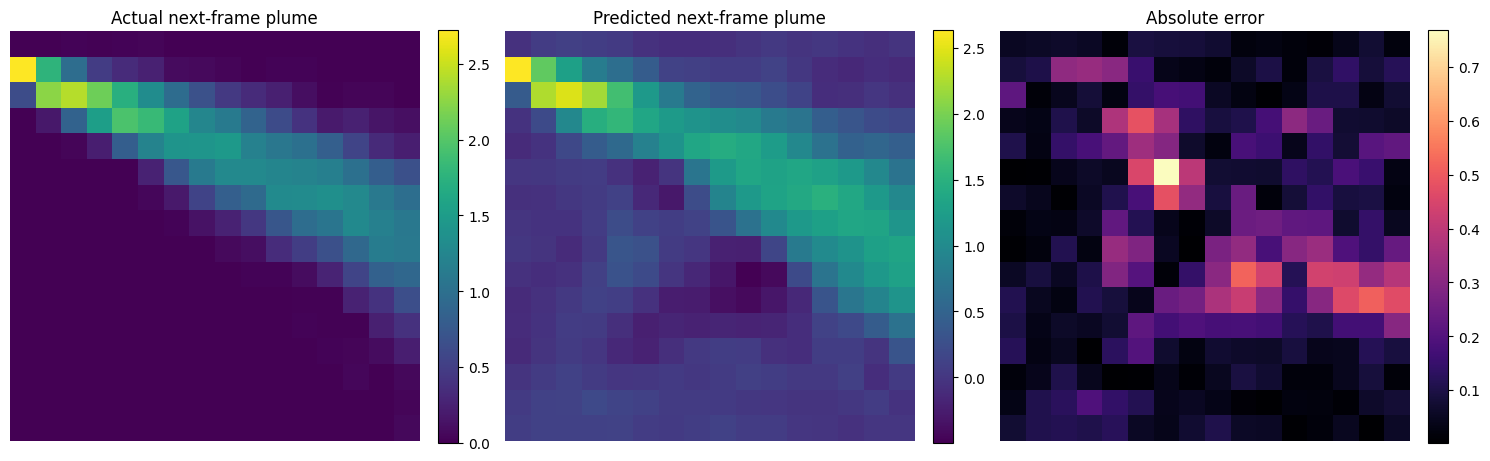

c:\Users\joaoh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


Sample 1 file: 000003_001.npz
  RMSE: 0.150471
  R^2: nan



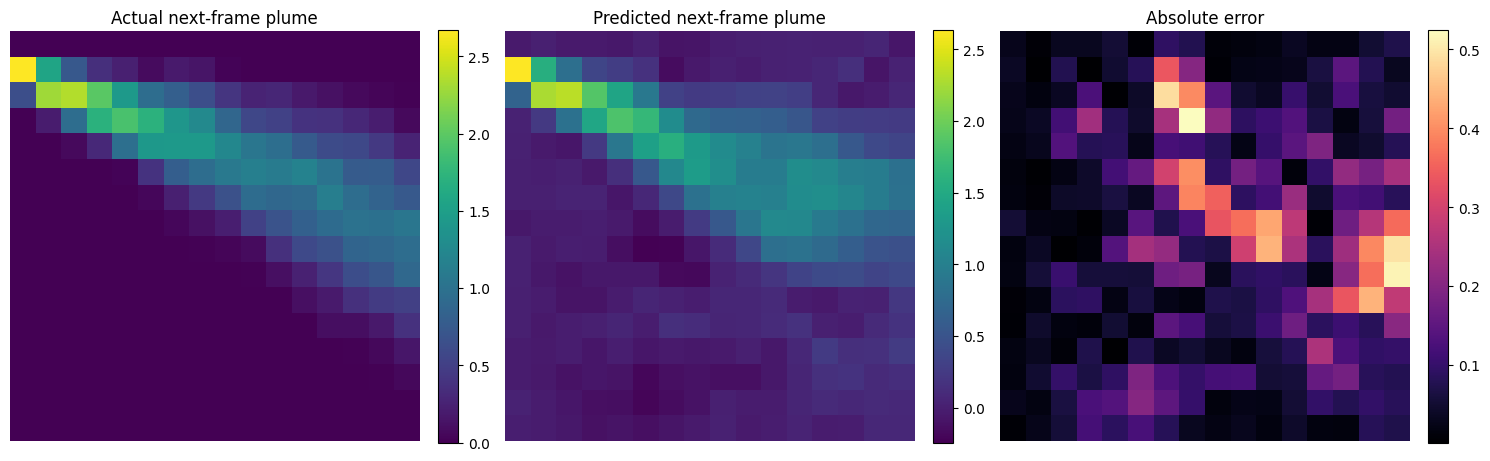

c:\Users\joaoh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


Sample 2 file: 000003_002.npz
  RMSE: 0.109227
  R^2: nan



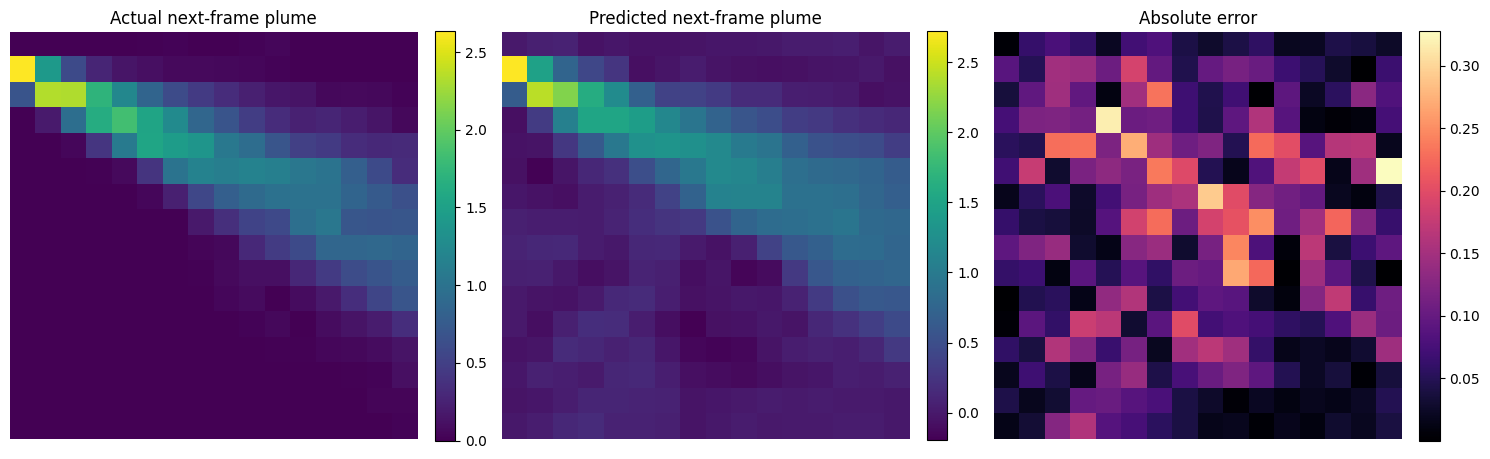

In [33]:
# Demo: predict and compare three sample windows

def run_demo_sample(index: int) -> None:
    demo_path = window_paths[index]
    with np.load(demo_path, allow_pickle=True) as demo_data:
        demo_input = demo_data["input"]
        demo_target = demo_data["target"]

    demo_features = extract_features(demo_input).reshape(1, -1)
    demo_true = extract_target(demo_target)
    demo_pred = model.predict(demo_features)[0]

    sample_rmse = np.sqrt(mean_squared_error(demo_true, demo_pred))
    sample_r2 = r2_score(demo_true.reshape(1, -1), demo_pred.reshape(1, -1), multioutput="uniform_average")

    print(f"Sample {index} file: {demo_path.name}")
    print(f"  RMSE: {sample_rmse:.6f}")
    print(f"  R^2: {sample_r2:.6f}\n")

    actual_grid = demo_true.reshape(16, 16)
    pred_grid = demo_pred.reshape(16, 16)
    error_grid = np.abs(actual_grid - pred_grid)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, grid, title, cmap in zip(
        axes,
        [actual_grid, pred_grid, error_grid],
        ["Actual next-frame plume", "Predicted next-frame plume", "Absolute error"],
        ["viridis", "viridis", "magma"],
    ):
        im = ax.imshow(grid, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

for sample_index in [0, 1, 2]:
    run_demo_sample(sample_index)

The rightmost plot shows the absolute error between predicted and actual plume concentration values in the downsampled 16×16 grid. Absolute error is positive only, so it measures the size of the mismatch without indicating whether the model over-predicted or under-predicted. Lower values mean the model is more accurate at that spatial location, and higher values show the grid cells where the prediction is least reliable.


# Summary

This notebook demonstrates a baseline training workflow for plume concentration forecasting using the EDA ConvLSTM dataset.

- Data shape is verified from `EDA/data/windows`
- The model predicts the next plume frame from three past frames and meteorology channels
- The trained model is saved as `trained_plume_model.pkl`
